# 🌫️ Air Quality Forecasting for Delhi NCR
## ML-Based Prediction of Pollutant Levels (SO2, NO2, CO, Aerosols)

This notebook demonstrates a complete pipeline for:
1. Fetching air quality data from Google Earth Engine
2. Preprocessing and feature engineering
3. Training multiple ML models
4. Forecasting future pollutant levels
5. Visualizing results

---

## 📦 1. Setup and Configuration

Import all modules and display configuration

In [1]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from config import *
from data_fetcher import GEEDataFetcher
from preprocessing import DataPreprocessor
from models import (
    ARIMAModel, ProphetModel, LSTMModel, 
    XGBoostModel, RandomForestModel, evaluate_model
)
from visualization import Visualizer

# Display configuration
print_config_summary()

AIR QUALITY FORECASTING - CONFIGURATION SUMMARY

📍 Region: Delhi
📅 Training Period: 2020-01-01 to 2022-12-31
🔮 Forecast Horizon: 30 days

🌫️  Active Pollutants: SO2, NO2, CO, Aerosol
🤖 Active Models: ARIMA, Prophet, LSTM, XGBoost, RandomForest
📊 Metrics: MAE, RMSE, MAPE, R2


## 🔐 2. Google Earth Engine Authentication

Authenticate with Google Earth Engine to access satellite data

In [2]:
# Initialize data fetcher
fetcher = GEEDataFetcher(REGION_CONFIG, GEE_CONFIG)

# Authenticate and initialize GEE
# Note: First time will open browser for authentication
fetcher.authenticate_and_initialize(project_id=GEE_CONFIG.get('project_id'))

# Load region
fetcher.load_region()

✅ Google Earth Engine initialized successfully!
✅ Loaded region: Delhi


## 📡 3. Fetch Data from Google Earth Engine

Download historical air quality data for Delhi NCR

In [3]:
# Fetch data for all active pollutants
raw_data = fetcher.fetch_all_pollutants(
    pollutants_config=POLLUTANTS,
    active_pollutants=ACTIVE_POLLUTANTS,
    start_date=TRAIN_START_DATE,
    end_date=TRAIN_END_DATE,
    scale=SPATIAL_SCALE,
    reducer=REDUCER
)

# Display sample data
print("\n📊 Sample Data:")
print(raw_data.head(10))
print(f"\nShape: {raw_data.shape}")
print(f"\nData Info:")
print(raw_data.info())

📡 Fetching SO2 data from 2020-01-01 to 2022-12-31 (monthly)...
📡 Fetching NO2 data from 2020-01-01 to 2022-12-31 (monthly)...
📡 Fetching CO data from 2020-01-01 to 2022-12-31 (monthly)...
📡 Fetching Aerosol data from 2020-01-01 to 2022-12-31 (monthly)...
✅ Fetched 36 records for SO2
  ✅ SO2 complete (1/4)
✅ Fetched 36 records for NO2
  ✅ NO2 complete (2/4)
✅ Fetched 36 records for CO
  ✅ CO complete (3/4)
✅ Fetched 36 records for Aerosol
  ✅ Aerosol complete (4/4)

⚠️  Polars not available, using Pandas

📊 Final dataset:
  Records: 36
  Date range: 2020-01-01 to 2022-12-01
  Pollutants: SO2, NO2, CO, Aerosol

📊 Sample Data:
         date       SO2       NO2        CO   Aerosol
0  2020-01-01  0.000409  0.000184  0.040909 -1.168942
1  2020-02-01  0.000273  0.000144  0.042983 -1.165007
2  2020-03-01  0.000150  0.000130  0.039741 -1.068222
3  2020-04-01  0.000159  0.000090  0.039512 -0.805518
4  2020-05-01  0.000117  0.000112  0.042252 -0.368144
5  2020-06-01  0.000048  0.000124  0.040059 

In [4]:
# Save raw data
if EXPORT_CONFIG['save_raw_data']:
    import os
    os.makedirs(EXPORT_CONFIG['data_dir'], exist_ok=True)
    
    filename = f"{EXPORT_CONFIG['data_dir']}/raw_data.csv"
    raw_data.to_csv(filename, index=False)
    print(f"💾 Raw data saved to {filename}")

💾 Raw data saved to data/raw_data.csv


## 📈 4. Visualize Raw Data

Plot time series of pollutant concentrations

💾 Saved plot to outputs/raw_timeseries.png


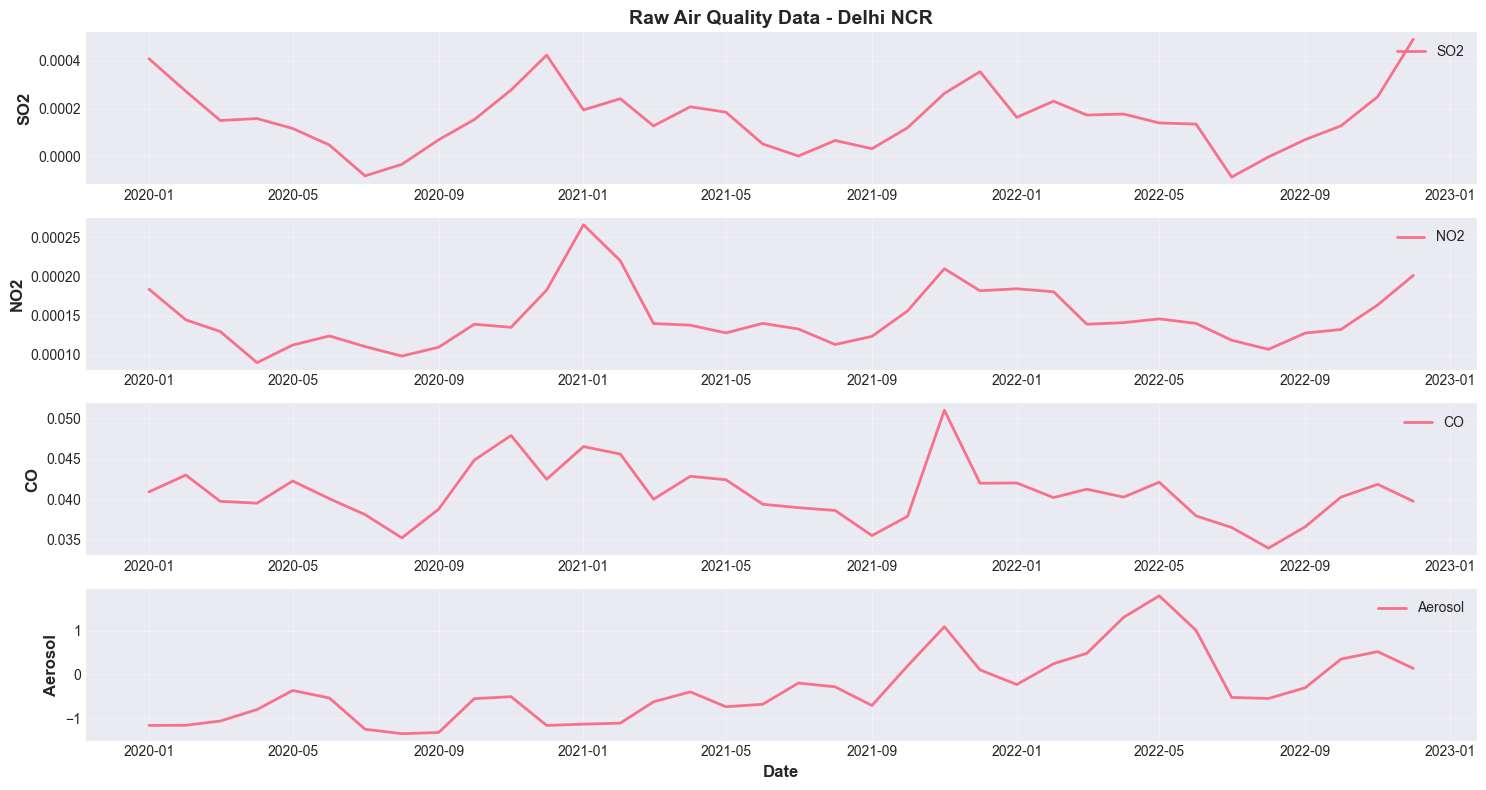

In [5]:
# Initialize visualizer
viz = Visualizer(VIS_CONFIG)

# Plot all pollutants
viz.plot_timeseries(
    df=raw_data,
    columns=ACTIVE_POLLUTANTS,
    title="Raw Air Quality Data - Delhi NCR",
    save_path=f"{VIS_CONFIG['output_dir']}/raw_timeseries.png" if VIS_CONFIG['save_plots'] else None
)

## 🧹 5. Data Preprocessing

Clean data and create features for ML models

In [6]:
# Initialize preprocessor
preprocessor = DataPreprocessor(FEATURE_CONFIG)

# Clean data
cleaned_data = preprocessor.clean_data(
    df=raw_data,
    interpolation_method=INTERPOLATION_METHOD,
    max_missing_days=MAX_MISSING_DAYS
)

print("\n✅ Cleaned data shape:", cleaned_data.shape)

🧹 Cleaning data...
  ⚠️  SO2: 1030 missing values
  ⚠️  NO2: 1030 missing values
  ⚠️  CO: 1030 missing values
  ⚠️  Aerosol: 1030 missing values
✅ Data cleaned: 1066 records

✅ Cleaned data shape: (1066, 5)


In [7]:
# Create all features
featured_data = preprocessor.create_all_features(
    df=cleaned_data,
    target_cols=ACTIVE_POLLUTANTS
)

print("\n📊 Feature columns created:")
print(f"Total features: {len(featured_data.columns)}")
print("\nSample features:")
print(featured_data.columns.tolist()[:20])


🔧 Feature Engineering Pipeline
📅 Creating 7 temporal features...
📊 Creating lag features for 5 time steps...
📊 Creating rolling features for 3 windows...

📉 Dropped 30 rows due to feature creation
✅ Final dataset: 1036 rows, 84 columns

📊 Feature columns created:
Total features: 84

Sample features:
['date', 'SO2', 'NO2', 'CO', 'Aerosol', 'day_of_week', 'day_of_month', 'month', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'SO2_lag_1', 'SO2_lag_3', 'SO2_lag_7', 'SO2_lag_14']


💾 Saved correlation matrix to outputs/correlation_matrix.png


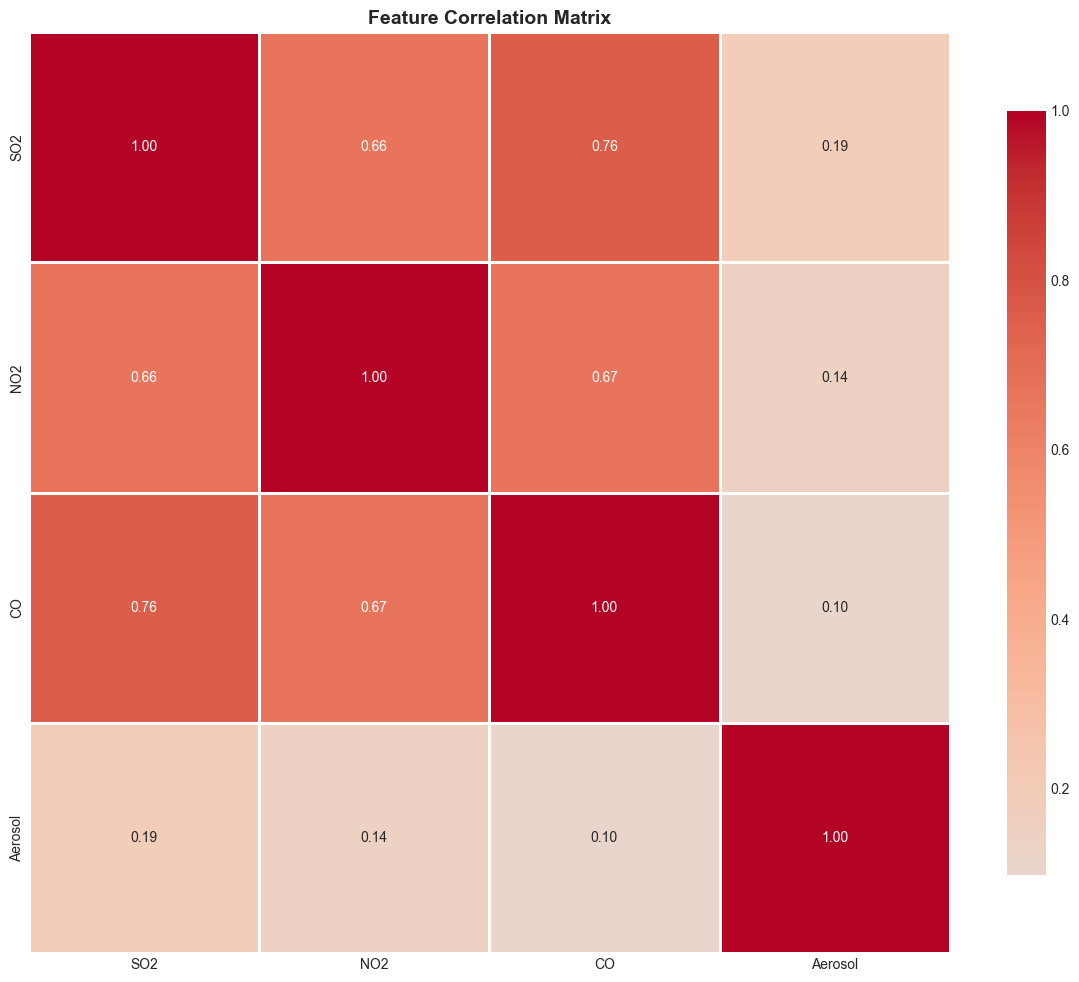

In [8]:
# Plot correlation matrix for original pollutants
viz.plot_correlation_matrix(
    df=featured_data,
    columns=ACTIVE_POLLUTANTS,
    save_path=f"{VIS_CONFIG['output_dir']}/correlation_matrix.png" if VIS_CONFIG['save_plots'] else None
)

## 🔀 6. Train-Test Split

Split data chronologically for time-series forecasting

In [9]:
# Split data
train_df, val_df, test_df = preprocessor.train_test_split(
    df=featured_data,
    test_size=VALIDATION_SPLIT,
    validation_size=0.1
)

print("\n✅ Data split complete!")


📊 Data Split:
  Train: 745 samples (2020-01-31 00:00:00 to 2022-02-13 00:00:00)
  Validation: 83 samples (2022-02-14 00:00:00 to 2022-05-07 00:00:00)
  Test: 208 samples (2022-05-08 00:00:00 to 2022-12-01 00:00:00)

✅ Data split complete!


## 🤖 7. Train ML Models

Train multiple forecasting models for each pollutant

In [10]:
# Select pollutant to forecast (change this to forecast different pollutants)
TARGET_POLLUTANT = 'NO2'  # Options: 'SO2', 'NO2', 'CO', 'Aerosol'

print(f"\n🎯 Target Pollutant: {TARGET_POLLUTANT}")
print(f"Unit: {POLLUTANTS[TARGET_POLLUTANT]['unit']}")


🎯 Target Pollutant: NO2
Unit: mol/m²


In [11]:
# Prepare data for ML models (exclude date and target)
feature_cols = [col for col in train_df.columns if col not in ['date', TARGET_POLLUTANT]]

X_train = train_df[feature_cols]
y_train = train_df[TARGET_POLLUTANT]

X_val = val_df[feature_cols]
y_val = val_df[TARGET_POLLUTANT]

X_test = test_df[feature_cols]
y_test = test_df[TARGET_POLLUTANT]

print(f"\nTraining features shape: {X_train.shape}")
print(f"Training target shape: {y_train.shape}")


Training features shape: (745, 82)
Training target shape: (745,)


### 7.1 XGBoost Model

🔧 Training XGBoost model...
✅ XGBoost model trained

📊 XGBoost Performance:
  MAE:  0.000020
  RMSE: 0.000023
  MAPE: 15.46%
  R²:   -0.3998
💾 Saved feature importance plot to outputs/feature_importance_xgb.png


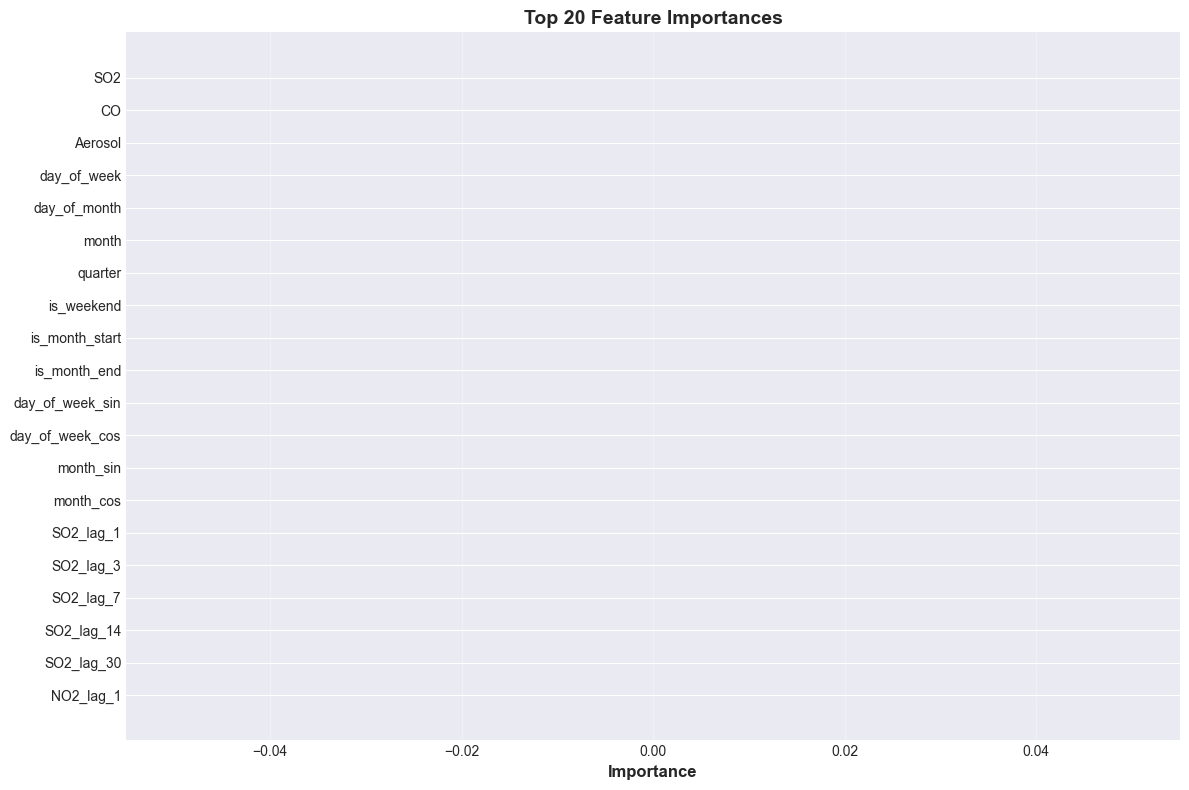

In [12]:
# Train XGBoost
if MODEL_CONFIG['XGBoost']['enabled']:
    xgb_model = XGBoostModel(MODEL_CONFIG['XGBoost'])
    xgb_model.fit(X_train, y_train)
    
    # Predict on test set
    xgb_pred = xgb_model.predict(X_test)
    
    # Evaluate
    xgb_metrics = evaluate_model(y_test.values, xgb_pred, "XGBoost")
    
    # Feature importance
    importance = xgb_model.get_feature_importance()
    viz.plot_feature_importance(
        importance_dict=importance,
        top_n=20,
        save_path=f"{VIS_CONFIG['output_dir']}/feature_importance_xgb.png" if VIS_CONFIG['save_plots'] else None
    )

### 7.2 Random Forest Model

In [13]:
# Train Random Forest
if MODEL_CONFIG['RandomForest']['enabled']:
    rf_model = RandomForestModel(MODEL_CONFIG['RandomForest'])
    rf_model.fit(X_train, y_train)
    
    # Predict on test set
    rf_pred = rf_model.predict(X_test)
    
    # Evaluate
    rf_metrics = evaluate_model(y_test.values, rf_pred, "Random Forest")

🔧 Training Random Forest model...
✅ Random Forest model trained

📊 Random Forest Performance:
  MAE:  0.000002
  RMSE: 0.000004
  MAPE: 1.88%
  R²:   0.9553


### 7.3 Prophet Model

In [14]:
# Train Prophet (requires different data format)
if MODEL_CONFIG['Prophet']['enabled']:
    try:
        prophet_model = ProphetModel(MODEL_CONFIG['Prophet'])
        
        # Prepare data for Prophet
        prophet_train = pd.DataFrame({
            'ds': train_df['date'],
            'y': train_df[TARGET_POLLUTANT]
        })
        
        prophet_model.fit(prophet_train)
        
        # Create future dataframe for test period
        future_test = pd.DataFrame({'ds': test_df['date']})
        prophet_forecast = prophet_model.predict(future_test)
        prophet_pred = prophet_forecast['yhat'].values
        
        # Evaluate
        prophet_metrics = evaluate_model(y_test.values, prophet_pred, "Prophet")
        
    except Exception as e:
        print(f"⚠️  Prophet training failed: {e}")

00:27:30 - cmdstanpy - INFO - Chain [1] start processing


🔧 Training Prophet model...


00:27:31 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model trained

📊 Prophet Performance:
  MAE:  0.000041
  RMSE: 0.000043
  MAPE: 31.07%
  R²:   -3.8967


### 7.4 ARIMA Model

In [15]:
# Train ARIMA
if MODEL_CONFIG['ARIMA']['enabled']:
    try:
        arima_model = ARIMAModel(MODEL_CONFIG['ARIMA'])
        arima_model.fit(train_df[TARGET_POLLUTANT])
        
        # Predict
        arima_pred = arima_model.predict(steps=len(test_df))
        
        # Evaluate
        arima_metrics = evaluate_model(y_test.values, arima_pred, "ARIMA")
        
    except Exception as e:
        print(f"⚠️  ARIMA training failed: {e}")

🔧 Training ARIMA model...
✅ ARIMA model trained

📊 ARIMA Performance:
  MAE:  0.000037
  RMSE: 0.000051
  MAPE: 24.82%
  R²:   -6.0721


## 📊 8. Model Comparison

Compare performance of all models


📊 Model Performance Comparison:
                    MAE      RMSE       MAPE        R2
XGBoost        0.000020  0.000023  15.455128 -0.399797
Random Forest  0.000002  0.000004   1.884502  0.955328
Prophet        0.000041  0.000043  31.065986 -3.896718
ARIMA          0.000037  0.000051  24.824858 -6.072125
💾 Saved comparison plot to outputs/model_comparison.png


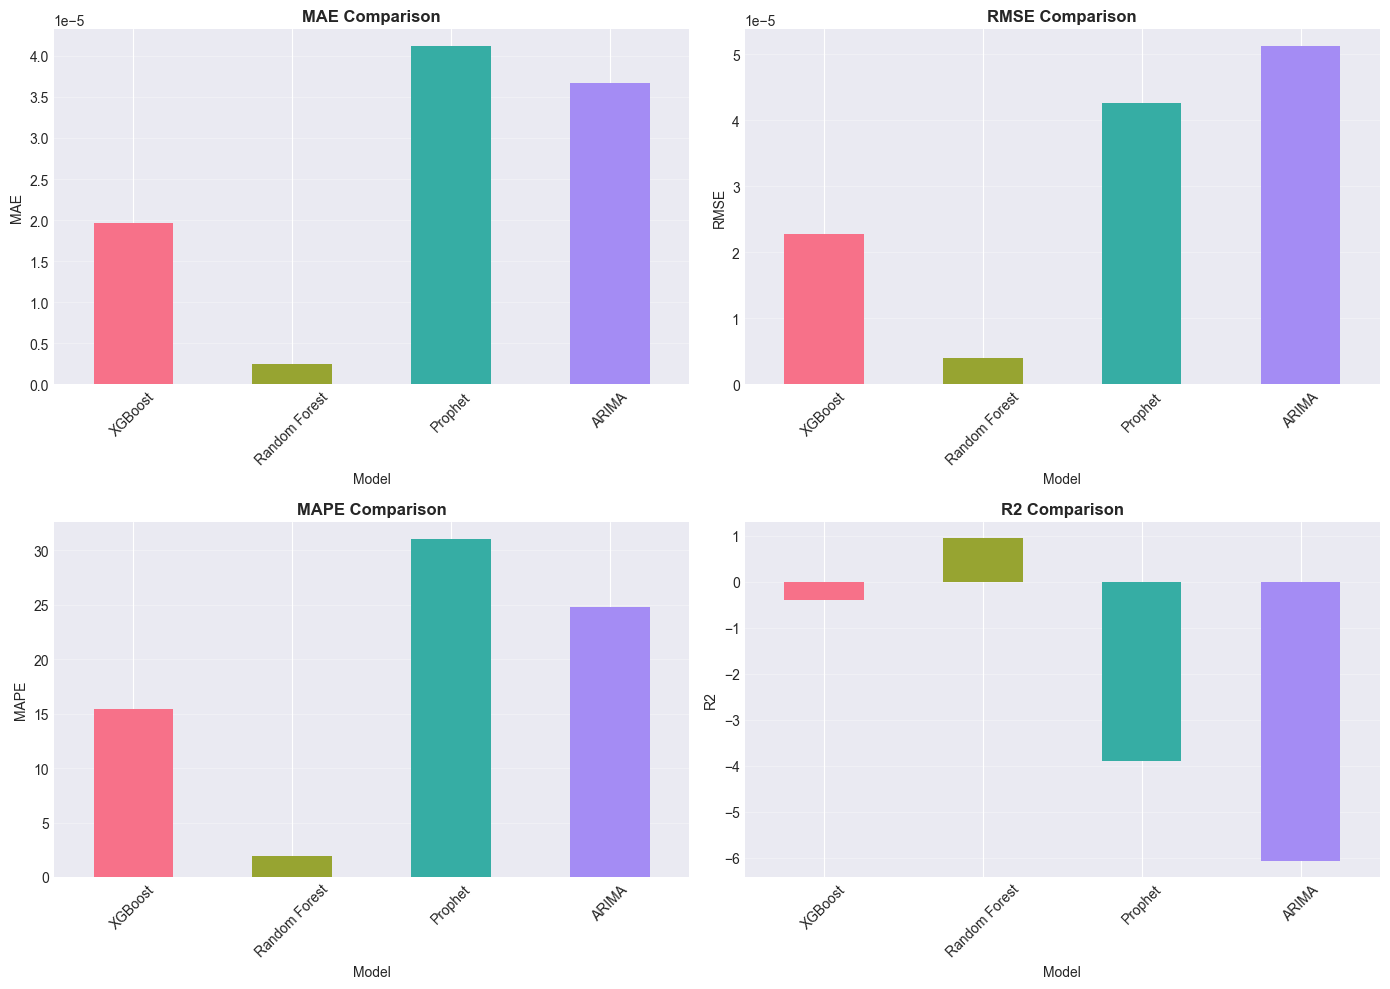

In [16]:
# Compile all metrics
all_metrics = {}

if 'xgb_metrics' in locals():
    all_metrics['XGBoost'] = xgb_metrics
if 'rf_metrics' in locals():
    all_metrics['Random Forest'] = rf_metrics
if 'prophet_metrics' in locals():
    all_metrics['Prophet'] = prophet_metrics
if 'arima_metrics' in locals():
    all_metrics['ARIMA'] = arima_metrics

# Create comparison DataFrame
metrics_df = pd.DataFrame(all_metrics).T

print("\n📊 Model Performance Comparison:")
print(metrics_df.to_string())

# Plot comparison
viz.plot_model_comparison(
    metrics_df=metrics_df,
    save_path=f"{VIS_CONFIG['output_dir']}/model_comparison.png" if VIS_CONFIG['save_plots'] else None
)

## 🔮 9. Future Forecasting

Generate forecasts for the next N days

In [17]:
# Select best model (based on lowest RMSE)
best_model_name = metrics_df['RMSE'].idxmin()
print(f"\n🏆 Best Model: {best_model_name}")
print(f"RMSE: {metrics_df.loc[best_model_name, 'RMSE']:.6f}")

# Get forecast dates
last_date = test_df['date'].max()
forecast_dates = pd.date_range(
    start=last_date + timedelta(days=1),
    periods=FORECAST_DAYS,
    freq='D'
)

print(f"\n📅 Forecasting from {forecast_dates[0]} to {forecast_dates[-1]}")


🏆 Best Model: Random Forest
RMSE: 0.000004

📅 Forecasting from 2022-12-02 00:00:00 to 2022-12-31 00:00:00


In [18]:
# Generate forecast using best model
# Note: For production, you'd need to create features for future dates
# This is a simplified example using the test set predictions

if best_model_name == 'XGBoost' and 'xgb_model' in locals():
    best_predictions = xgb_pred
elif best_model_name == 'Random Forest' and 'rf_model' in locals():
    best_predictions = rf_pred
elif best_model_name == 'Prophet' and 'prophet_model' in locals():
    best_predictions = prophet_pred
elif best_model_name == 'ARIMA' and 'arima_model' in locals():
    best_predictions = arima_pred

print(f"\n✅ Generated {len(best_predictions)} predictions")


✅ Generated 208 predictions


## 📈 10. Visualize Forecasts

Plot historical data and forecasts

💾 Saved forecast plot to outputs/forecast_NO2.png


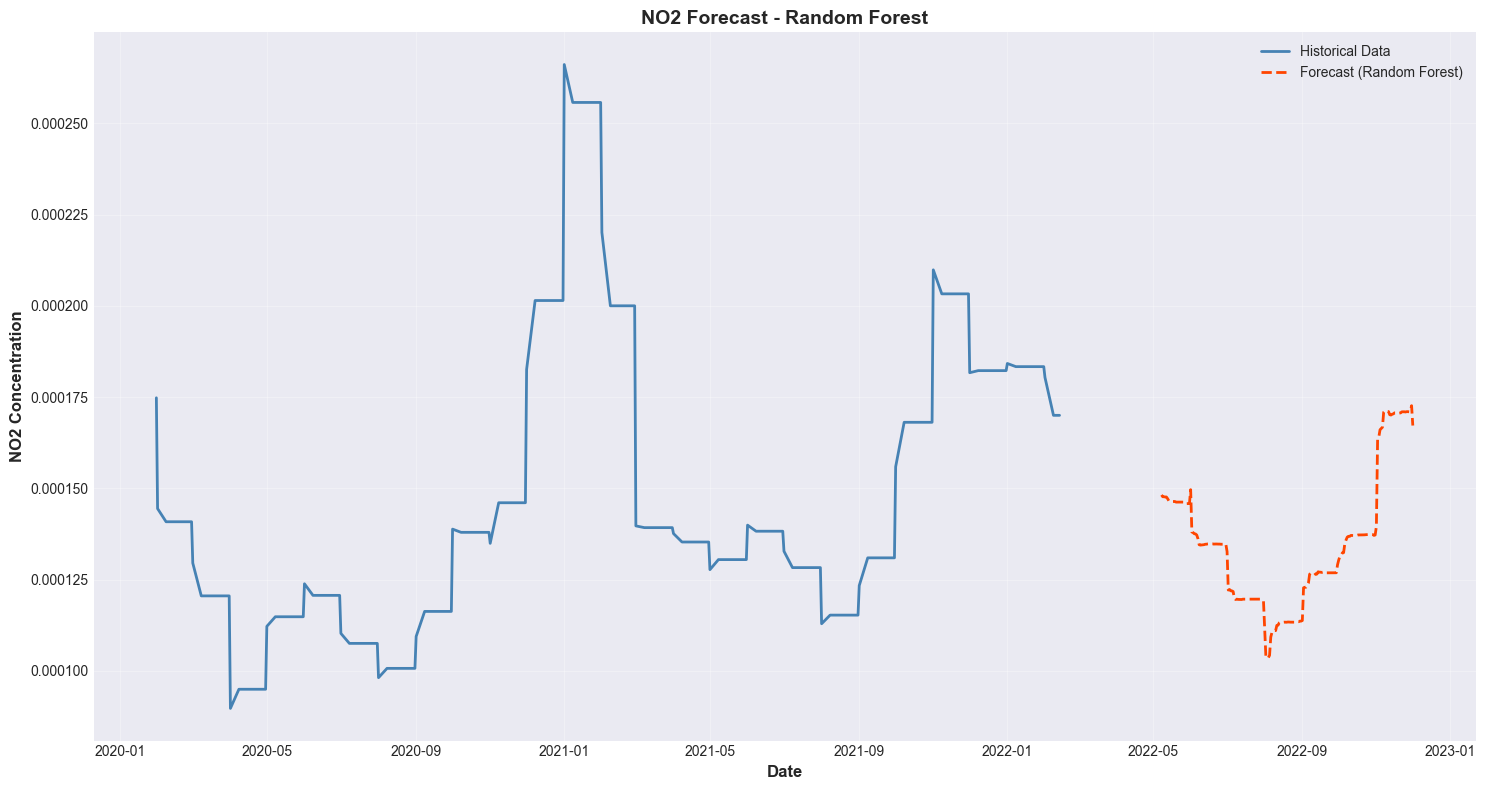

In [19]:
# Plot forecast with historical data
viz.plot_forecast(
    historical_dates=train_df['date'],
    historical_values=train_df[TARGET_POLLUTANT].values,
    forecast_dates=test_df['date'],
    forecast_values=best_predictions,
    pollutant_name=TARGET_POLLUTANT,
    model_name=best_model_name,
    save_path=f"{VIS_CONFIG['output_dir']}/forecast_{TARGET_POLLUTANT}.png" if VIS_CONFIG['save_plots'] else None
)

💾 Saved comparison plot to outputs/all_forecasts_NO2.png


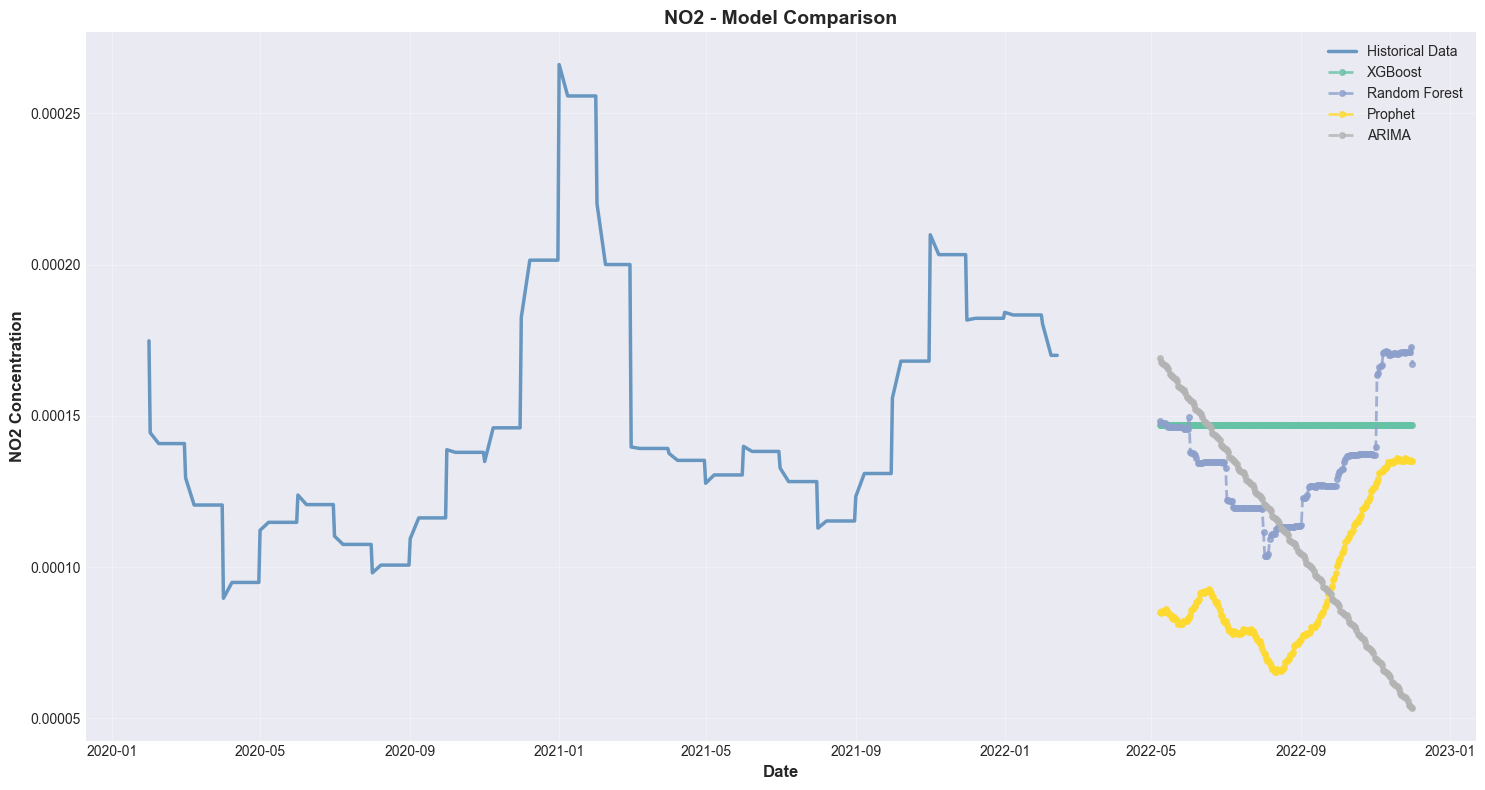

In [20]:
# Plot all model forecasts together
forecasts_dict = {}

if 'xgb_pred' in locals():
    forecasts_dict['XGBoost'] = (test_df['date'], xgb_pred)
if 'rf_pred' in locals():
    forecasts_dict['Random Forest'] = (test_df['date'], rf_pred)
if 'prophet_pred' in locals():
    forecasts_dict['Prophet'] = (test_df['date'], prophet_pred)
if 'arima_pred' in locals():
    forecasts_dict['ARIMA'] = (test_df['date'], arima_pred)

viz.plot_multiple_forecasts(
    historical_dates=train_df['date'],
    historical_values=train_df[TARGET_POLLUTANT].values,
    forecasts=forecasts_dict,
    pollutant_name=TARGET_POLLUTANT,
    save_path=f"{VIS_CONFIG['output_dir']}/all_forecasts_{TARGET_POLLUTANT}.png" if VIS_CONFIG['save_plots'] else None
)

## 💾 11. Save Results

Export predictions and model metrics

In [21]:
# Save predictions
if EXPORT_CONFIG['save_predictions']:
    import os
    os.makedirs(EXPORT_CONFIG['data_dir'], exist_ok=True)
    
    # Create predictions DataFrame
    predictions_df = pd.DataFrame({
        'date': test_df['date'],
        'actual': y_test.values,
        'predicted': best_predictions,
        'model': best_model_name,
        'pollutant': TARGET_POLLUTANT
    })
    
    filename = f"{EXPORT_CONFIG['data_dir']}/predictions_{TARGET_POLLUTANT}.csv"
    predictions_df.to_csv(filename, index=False)
    print(f"💾 Predictions saved to {filename}")
    
    # Save metrics
    metrics_filename = f"{EXPORT_CONFIG['data_dir']}/model_metrics_{TARGET_POLLUTANT}.csv"
    metrics_df.to_csv(metrics_filename)
    print(f"💾 Metrics saved to {metrics_filename}")

💾 Predictions saved to data/predictions_NO2.csv
💾 Metrics saved to data/model_metrics_NO2.csv


## 📋 12. Summary

Final summary of the analysis

In [22]:
print("="*70)
print("🎯 AIR QUALITY FORECASTING - SUMMARY")
print("="*70)
print(f"\n📍 Region: {REGION_CONFIG['name']}")
print(f"🌫️  Target Pollutant: {TARGET_POLLUTANT}")
print(f"📅 Training Period: {TRAIN_START_DATE} to {TRAIN_END_DATE}")
print(f"📊 Total Data Points: {len(raw_data)}")
print(f"🔧 Features Created: {len(feature_cols)}")
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   - RMSE: {metrics_df.loc[best_model_name, 'RMSE']:.6f}")
print(f"   - MAE:  {metrics_df.loc[best_model_name, 'MAE']:.6f}")
print(f"   - R²:   {metrics_df.loc[best_model_name, 'R2']:.4f}")
print(f"\n🔮 Forecast Horizon: {FORECAST_DAYS} days")
print("\n✅ Analysis Complete!")
print("="*70)

🎯 AIR QUALITY FORECASTING - SUMMARY

📍 Region: Delhi
🌫️  Target Pollutant: NO2
📅 Training Period: 2020-01-01 to 2022-12-31
📊 Total Data Points: 36
🔧 Features Created: 82

🏆 Best Model: Random Forest
   - RMSE: 0.000004
   - MAE:  0.000002
   - R²:   0.9553

🔮 Forecast Horizon: 30 days

✅ Analysis Complete!


## 🚀 Next Steps

To forecast other pollutants:
1. Change `TARGET_POLLUTANT` in cell "7. Train ML Models"
2. Re-run cells from section 7 onwards

To adjust date ranges:
1. Modify `TRAIN_START_DATE` and `TRAIN_END_DATE` in `config.py`
2. Re-run the entire notebook

To try different models:
1. Enable/disable models in `MODEL_CONFIG` in `config.py`
2. Adjust hyperparameters in the same config
3. Re-run from section 7

---

**Note:** All outputs are saved in the `outputs/` and `data/` directories as configured.

In [23]:
# Import Complete Analysis Module
from complete_analysis import CompleteAnalysis
from spatial_mapper import SpatialMapper
from config import SPATIAL_MAP_CONFIG

print("✅ Complete analysis module imported")

✅ Complete analysis module imported


## 🗺️ Complete Analysis with Spatial Mapping

This section runs the complete analysis pipeline for **ALL pollutants**:
- Fetches data for all active pollutants
- Trains all enabled ML models
- Generates predictions and forecasts
- Creates visualizations for each pollutant
- Generates geographical color-coded maps
- Saves all outputs with time evolution

**Pixel Density Control:**
- `ultra_high` (100m): Very detailed, slow processing
- `high` (500m): Detailed
- `medium` (1000m): Balanced (default)
- `low` (2000m): Faster processing
- `ultra_low` (5000m): Very fast, less detail

In [24]:
# Configure Analysis
analysis = CompleteAnalysis()

# Optional: Adjust pixel density for spatial maps
# analysis.mapper.set_pixel_density(SPATIAL_MAP_CONFIG['pixel_density_presets']['high'])

print("Starting complete analysis for all pollutants...")
print("This will:")
print("  1. Fetch data for all active pollutants")
print("  2. Train all enabled ML models")
print("  3. Generate predictions and forecasts")
print("  4. Create time series visualizations")
print("  5. Generate geographical maps showing pollutant evolution")
print("  6. Save all outputs")
print("\nThis may take several minutes...\n")

# Run complete analysis
results = analysis.run_complete_analysis()

Starting complete analysis for all pollutants...
This will:
  1. Fetch data for all active pollutants
  2. Train all enabled ML models
  3. Generate predictions and forecasts
  4. Create time series visualizations
  5. Generate geographical maps showing pollutant evolution
  6. Save all outputs

This may take several minutes...


STARTING COMPLETE ANALYSIS PIPELINE
INITIALIZING AIR QUALITY ANALYSIS PIPELINE
✅ Google Earth Engine initialized successfully!


TypeError: DataPreprocessor.__init__() missing 1 required positional argument: 'feature_config'

In [ ]:
# Display Results Summary
print("=" * 70)
print("ANALYSIS RESULTS SUMMARY")
print("=" * 70)

for pollutant, result in results.items():
    print(f"\n{pollutant}:")
    print(f"  Models trained: {len(result['models'])}")
    print(f"  Visualizations created: {len(result['plots'])}")
    print(f"  Spatial maps created: {len(result['maps'])}")
    
    if result['metrics']:
        print(f"\n  Best Model Performance:")
        best_model = min(result['metrics'].items(), 
                        key=lambda x: x[1].get('RMSE', float('inf')))
        print(f"    Model: {best_model[0]}")
        for metric, value in best_model[1].items():
            print(f"    {metric}: {value:.6f}")

print(f"\n📁 All outputs saved in:")
for name, path in analysis.output_dirs.items():
    print(f"   {name}: {path}/")

## 📍 View Spatial Maps

The geographical maps have been created in the `outputs/maps/` directory.

Each map shows:
- **Color-coded pollutant density** across Delhi-NCR
- **Region boundary** in red
- **Colorbar legend** showing concentration levels
- **Interactive layers** (for multi-pollutant maps)

To view a map, open the HTML file in your browser.

In [ ]:
# Create Custom Spatial Maps

# Example: Create map for specific pollutant and date
from spatial_mapper import quick_map

# Create single pollutant map
m = quick_map(
    pollutant='NO2',
    date='2022-06-01',
    region='Delhi',
    pixel_density=1000  # Adjust for detail level
)

print("✅ Custom map created in outputs/maps/")

# Example: Create time series of maps
# Uncomment to create monthly evolution maps:
'''
mapper = analysis.mapper
maps = mapper.create_time_series_maps(
    pollutant_name='NO2',
    start_date='2022-01-01',
    end_date='2022-12-31',
    interval_days=30  # One map per month
)
print(f"✅ Created {len(maps)} time evolution maps")
'''

In [ ]:
# Export High-Resolution GeoTIFF Images

# Export to Google Drive for GIS analysis
# Uncomment to export:
'''
for pollutant in ACTIVE_POLLUTANTS:
    task = analysis.mapper.export_high_res_image(
        pollutant_name=pollutant,
        date_str='2022-06-01'
    )
    print(f"Export task started for {pollutant}")

print("\nCheck your Google Drive 'GEE_Exports' folder for GeoTIFF files")
'''

## 🔬 Understanding Pixel Density

**Pixel density** controls the resolution of spatial maps:

| Preset | Meters/Pixel | Detail Level | Processing Speed | Use Case |
|--------|--------------|--------------|------------------|----------|
| ultra_high | 100m | Very High | Slow | Detailed analysis |
| high | 500m | High | Moderate | Research |
| **medium** | **1000m** | **Balanced** | **Fast** | **Default** |
| low | 2000m | Low | Very Fast | Quick overview |
| ultra_low | 5000m | Very Low | Fastest | Regional view |

**Trade-offs:**
- Lower pixel density = More detail but slower data fetching
- Higher pixel density = Less detail but faster processing
- Data volume increases exponentially with higher resolution

## 📊 Next Steps

Your complete analysis is done! Here's what you have:

### Outputs Generated:
1. **Data**: `data/` - Raw and processed data
2. **Models**: `outputs/models/` - Trained model files
3. **Plots**: `outputs/plots/` - Time series and prediction charts
4. **Maps**: `outputs/maps/` - Interactive geographical maps
5. **Predictions**: `outputs/predictions/` - Forecast data and metrics
6. **Reports**: `outputs/reports/` - Summary reports

### To Explore Results:
- Open HTML maps in `outputs/maps/` to see pollutant distribution
- Check prediction accuracy in `outputs/predictions/*_metrics.json`
- View time series evolution in `outputs/plots/`
- Read summary in `outputs/reports/analysis_summary.txt`

### To Rerun with Different Settings:
- Adjust pixel density in config.py
- Enable/disable models in MODEL_CONFIG
- Change date ranges in config.py
- Modify ACTIVE_POLLUTANTS list